## Midterm Group Project
Date: 06/25/2026

Class: ITAI2372, Professor Ganti

Group members:
- Denae Liong
- Chrishandra Lewich
- Chinonyelum Igwe



Dataset: https://www.kaggle.com/datasets/rmisra/news-category-dataset

## Project Overview
This project builds a NewsBot Intelligence System that processes, analyzes, classifies, and extracts insights from news articles using NLP techniques from Modules 1–8.

# Project Setup

Before beginning the NLP pipeline, the dataset must be downloaded, explored, and prepared for analysis. This section installs the required libraries, loads the News Category Dataset, and prepares the data that will be used throughout the remainder of the project.

### A. Install Required Libraries

In [ ]:
# Install required libraries

!pip install kagglehub
!pip install kaggle
!pip install textblob

In [ ]:
# Import required libraries

import kagglehub
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

### B. Download the Dataset

In [ ]:
# Download latest version

path = kagglehub.dataset_download("rmisra/news-category-dataset")

print("Path to dataset files:", path)

100%|██████████| 26.5M/26.5M [00:00<00:00, 108MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/rmisra/news-category-dataset/versions/3


### Analysis

The News Category Dataset was successfully downloaded from Kaggle using the KaggleHub library. This dataset contains over 200,000 news articles collected from HuffPost and serves as the foundation for building the NewsBot Intelligence System.

In [ ]:
!kaggle datasets download -d rmisra/news-category-dataset

!unzip -o news-category-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/rmisra/news-category-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 26.5M/26.5M [00:00<00:00, 69.6MB/s]

Archive:  news-category-dataset.zip
  inflating: News_Category_Dataset_v3.json  


### C. Load the Dataset
The dataset is stored as a JSON file where each line represents a single news article. In this step, the dataset is loaded into a pandas DataFrame so it can be explored and prepared for Natural Language Processing.

In [ ]:
# Load the JSON dataset

with open('News_Category_Dataset_v3.json', 'r') as f:
    data = [json.loads(line) for line in f]

df = pd.DataFrame(data)

print(f"Original dataset shape: {df.shape}")

print(f"Columns: {df.columns.tolist()}")

display(df.head())

Original dataset shape: (209527, 6)
Columns: ['link', 'headline', 'category', 'short_description', 'authors', 'date']


,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


### Analysis

The dataset was successfully loaded into a pandas DataFrame. Each row represents one news article and includes information such as the headline, category, short description, author, publication date, and article link. This provides the raw data that will be cleaned and processed throughout the remainder of the project.

### D. Prepare the Dataset
Before beginning the NLP workflow, the dataset must be cleaned and standardized. Since the NewsBot is designed to analyze news articles rather than headlines alone, the headline and short description are combined into a single text column. This provides more context for later NLP tasks such as TF-IDF analysis, sentiment analysis, text classification, and named entity recognition.

In [ ]:
# Data preparation

print("Dataset Info:")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

print("\nFirst few rows:")
print(df.head())

# Create one text column using both the headline and short description
df['content'] = (
    df['headline'].fillna('') + " " +
    df['short_description'].fillna('')
)

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Remove rows with missing text or categories
df_clean = df.dropna(subset=['content', 'category'])

# Check category distribution
print("\nCategory distribution:")
print(df_clean['category'].value_counts())

# Sample dataset
if len(df_clean) > 2000:
    df_final = df_clean.sample(n=2000, random_state=42)
else:
    df_final = df_clean

# Keep useful columns
df_final = df_final[
    [
        'link',
        'content',
        'category',
        'short_description',
        'authors',
        'date'
    ]
]

# Save processed dataset
df_final.to_csv("newsbot_dataset.csv", index=False)

print("\n✅ Dataset prepared and saved as 'newsbot_dataset.csv'")

Dataset Info:
Shape: (209527, 6)
Columns: ['link', 'headline', 'category', 'short_description', 'authors', 'date']

First few rows:
                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS   
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY   
3  The Funniest Tweets From Parents This Week (Se...  PARENTING   
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS   

                                   short_description               authors  \
0  Health experts said it is too early to predict.

### Analysis

The dataset was successfully prepared for the NewsBot project. The headline and short description were combined into a single text field to provide more context for Natural Language Processing tasks. Missing values were checked, the dataset was sampled to 2,000 articles for faster processing, and the cleaned dataset was saved as **newsbot_dataset.csv** for use throughout the remainder of the notebook.

### E. Dataset Visualization
Before beginning the NLP analysis, it is helpful to understand how the news articles are distributed across categories. Visualizing the dataset provides insight into the balance of the data and helps identify categories that may contain significantly more or fewer articles than others.

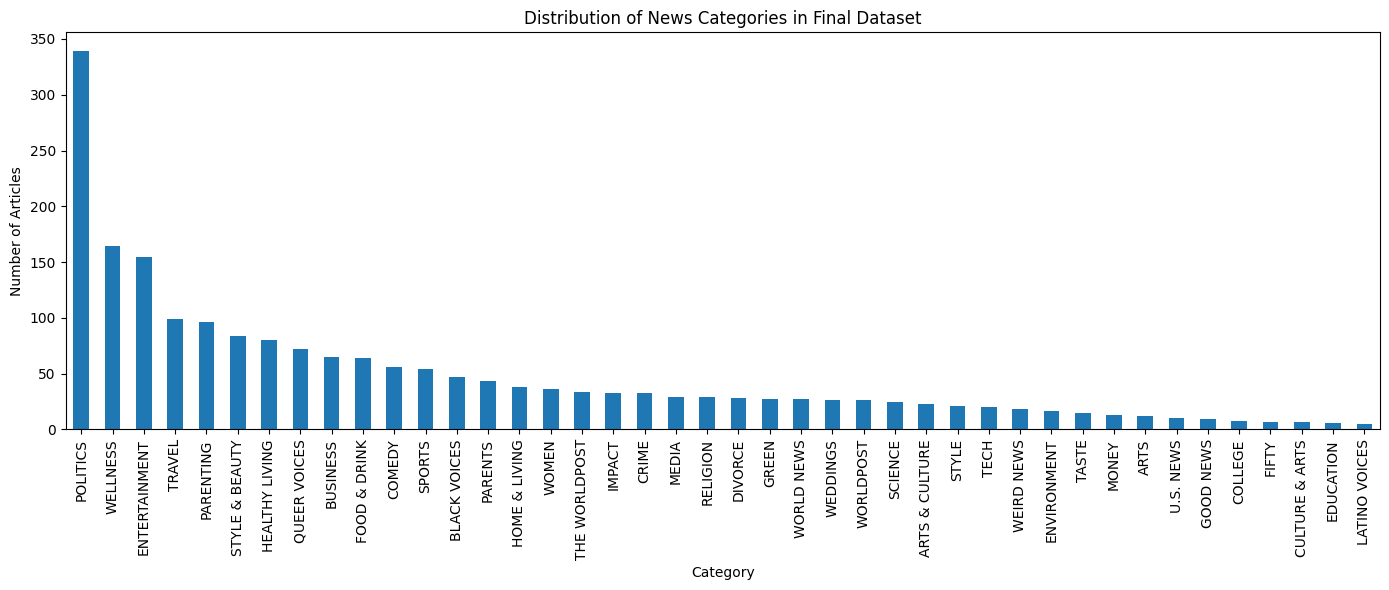

In [ ]:
category_counts = df_final['category'].value_counts()

plt.figure(figsize=(14,6))

category_counts.plot(kind='bar')

plt.title("Distribution of News Categories in Final Dataset")

plt.xlabel("Category")

plt.ylabel("Number of Articles")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

### Analysis

This chart shows the distribution of the news categories in the final dataset used for the NewsBot project. The dataset includes articles from a wide variety of topics, although some categories have noticeably more articles than others. This is important because an uneven distribution can affect how well the classification model learns each category. Looking at the data before building the model also helps us better understand the dataset we're working with and identify any potential imbalance.

# Module 1 – Real-World NLP Application Context

Module 1 focuses on understanding the real-world purpose of the NewsBot Intelligence System before applying Natural Language Processing techniques. Rather than simply processing text, the goal is to solve a practical business problem by automatically organizing and analyzing large collections of news articles.

### A. Business Problem
Organizations publish thousands of news articles every day, making it difficult to manually review, organize, and analyze large volumes of information. Businesses, researchers, media organizations, and government agencies need automated tools that can quickly classify articles, identify important entities, measure sentiment, and monitor trends across multiple topics.

The NewsBot Intelligence System addresses this challenge by using Natural Language Processing techniques to automatically process and analyze news content.

### B. Target Users
The NewsBot can support journalists, media organizations, researchers, business intelligence teams, cybersecurity analysts, and government agencies. These users can quickly identify important topics, organize articles into categories, monitor public sentiment, and track frequently mentioned people, organizations, and locations without manually reviewing thousands of news articles.

### C. Business Value
By combining multiple Natural Language Processing techniques into a single workflow, the NewsBot transforms unstructured news articles into organized and meaningful information. This allows users to make faster decisions, improve information retrieval, monitor emerging trends, and generate valuable business intelligence from large collections of news content.

# Module 2 – Preprocess News Articles Using Advanced Text Cleaning Techniques
Preprocess News Articles Using Advanced Text Cleaning Techniques Natural Language Processing models perform better when the text has been cleaned and standardized. In this module, the raw news articles are preprocessed by converting text to lowercase, removing punctuation, removing stop words, and applying lemmatization. These steps reduce unnecessary noise while preserving the important meaning of the text.

### A. Load Dataset for Processing
The prepared dataset created during the project setup is loaded so that the preprocessing pipeline can be applied. NLTK resources are also loaded to support tokenization, stop word removal, and lemmatization.

In [ ]:
import re
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download required NLTK resources
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("punkt")
nltk.download("punkt_tab")

# Load prepared dataset
df_processed = pd.read_csv("newsbot_dataset.csv")

display(df_processed.head())


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,link,content,category,short_description,authors,date
0,https://www.huffingtonpost.com/entry/what-if-w...,What If We Were All Family Generation Changers...,IMPACT,"What if, in doing so, we won't just create new...","Matt Murrie, ContributorEdupreneur, Cofounder/...",2014-06-20
1,https://www.huffingtonpost.comhttp://www.washi...,Firestorm At AOL Over Employee Benefit Cuts It...,BUSINESS,It should have been a glorious week for AOL ch...,NaN,2014-02-08
2,https://www.huffingtonpost.com/entry/time-runs...,Dakota Access Protesters Arrested As Deadline ...,POLITICS,A few protesters who refused to leave remained...,"Michael McLaughlin & Josh Morgan, The Huffingt...",2017-02-22
3,https://www.huffingtonpost.com/entry/one-glimp...,One Glimpse Of These Baby Kit Foxes And You'll...,GREEN,NaN,NaN,2014-05-14
4,https://www.huffingtonpost.com/entry/mens-swea...,"Mens' Sweat Pheromone, Androstadienone, Influe...",SCIENCE,Scientists didn't know if humans played that g...,Melissa Cronin,2013-06-02


### Analysis

The prepared dataset was successfully loaded and is now ready for preprocessing. At this stage, the text still contains its original formatting and has not yet been cleaned. This provides a useful reference for comparing the original text with the cleaned version produced in the next step.

### B. Text Cleaning Pipeline
The text cleaning pipeline removes unnecessary information while preserving the important meaning of each news article. This process includes converting text to lowercase, removing punctuation and numbers, tokenizing the text, removing stop words, and lemmatizing the remaining words.

In [ ]:
# Initialize preprocessing tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def clean_text(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()

    # Remove punctuation and numbers
    text = re.sub(r'[\d\W_]+', ' ', text)

    # Tokenize
    tokens = nltk.word_tokenize(text)

    # Remove stop words and lemmatize
    cleaned_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    return " ".join(cleaned_tokens)

# Apply preprocessing
df_processed["cleaned_content"] = df_processed["content"].apply(clean_text)

# Display before and after cleaning
print("Original Content:\n")
print(df_processed["content"].iloc[0])

print("\nCleaned Content:\n")
print(df_processed["cleaned_content"].iloc[0])

display(df_processed.head())

Original Content:

What If We Were All Family Generation Changers? What if, in doing so, we won't just create new opportunities for ourselves, we'll also uncover ways to create new opportunities for our families that may not have otherwise existed?

Cleaned Content:

family generation changer create new opportunity also uncover way create new opportunity family may otherwise existed


,link,content,category,short_description,authors,date,cleaned_content
0,https://www.huffingtonpost.com/entry/what-if-w...,What If We Were All Family Generation Changers...,IMPACT,"What if, in doing so, we won't just create new...","Matt Murrie, ContributorEdupreneur, Cofounder/...",2014-06-20,family generation changer create new opportuni...
1,https://www.huffingtonpost.comhttp://www.washi...,Firestorm At AOL Over Employee Benefit Cuts It...,BUSINESS,It should have been a glorious week for AOL ch...,NaN,2014-02-08,firestorm aol employee benefit cut glorious we...
2,https://www.huffingtonpost.com/entry/time-runs...,Dakota Access Protesters Arrested As Deadline ...,POLITICS,A few protesters who refused to leave remained...,"Michael McLaughlin & Josh Morgan, The Huffingt...",2017-02-22,dakota access protester arrested deadline pass...
3,https://www.huffingtonpost.com/entry/one-glimp...,One Glimpse Of These Baby Kit Foxes And You'll...,GREEN,NaN,NaN,2014-05-14,one glimpse baby kit fox hooked
4,https://www.huffingtonpost.com/entry/mens-swea...,"Mens' Sweat Pheromone, Androstadienone, Influe...",SCIENCE,Scientists didn't know if humans played that g...,Melissa Cronin,2013-06-02,men sweat pheromone androstadienone influence ...


### Analysis

The preprocessing pipeline successfully transformed the raw news text into a cleaner and more consistent format. Converting text to lowercase, removing punctuation and stop words, and applying lemmatization reduced unnecessary noise while preserving the important meaning of the articles. The new **cleaned_content** column will serve as the primary input for all remaining Natural Language Processing tasks.

### C. Most Common Words After Cleaning
After preprocessing, the cleaned text can be explored to identify the most frequently occurring words across the dataset. This provides a quick overview of the dominant topics that remain after common words have been removed.

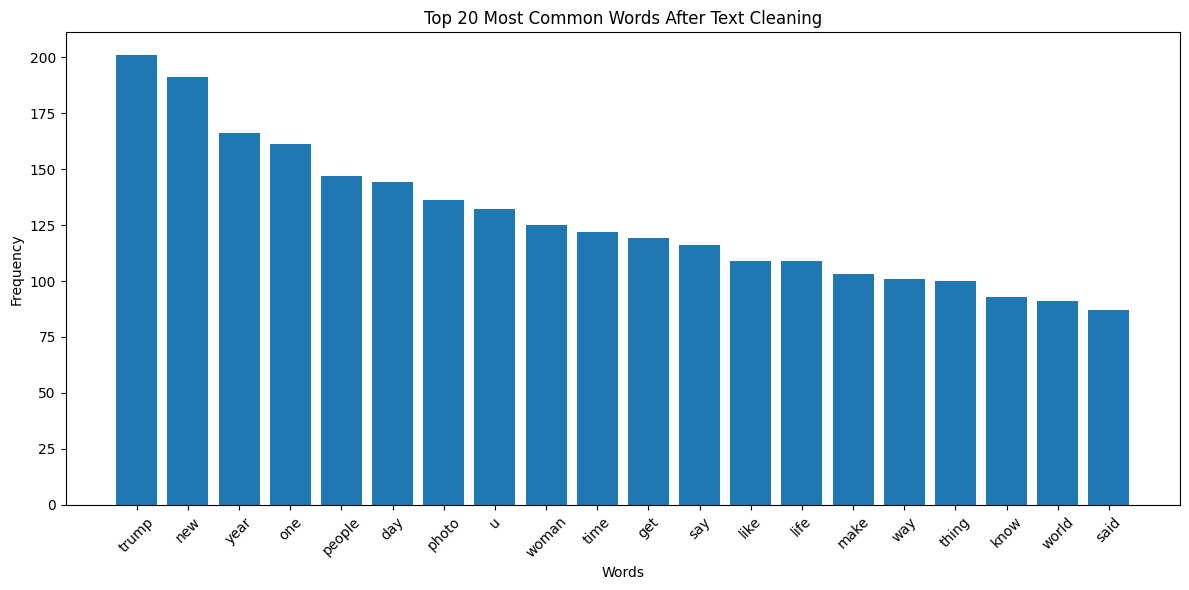

In [ ]:
from collections import Counter

# Count words
all_words = " ".join(df_processed["cleaned_content"]).split()

word_counts = Counter(all_words)

common_words = word_counts.most_common(20)

words = [word for word, count in common_words]
counts = [count for word, count in common_words]

# Create bar chart
plt.figure(figsize=(12, 6))

plt.bar(words, counts)

plt.title("Top 20 Most Common Words After Text Cleaning")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Analysis
This chart shows the most common words after the preprocessing step. Removing punctuation, stop words, and other unnecessary text leaves behind more meaningful terms that better represent the major topics discussed throughout the news articles. Cleaning the text reduces noise in the dataset and improves the quality of later NLP tasks such as TF-IDF analysis, sentiment analysis, and text classification.

# Module 3 – Identify Patterns Using TF-IDF
After preprocessing, the cleaned text is transformed into numerical features using Term Frequency–Inverse Document Frequency (TF-IDF). TF-IDF measures the importance of words within individual documents while reducing the influence of very common words that appear throughout the entire dataset.

### A. TF-IDF Feature Extraction
TF-IDF converts text into numerical vectors that machine learning algorithms can understand. Each word receives a score based on how important it is within a document compared to the rest of the dataset.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit the vectorizer and transform the cleaned text
tfidf_matrix = tfidf_vectorizer.fit_transform(
    df_processed["cleaned_content"]
)

# Get the feature names
feature_names = tfidf_vectorizer.get_feature_names_out()

# Display the shape of the TF-IDF matrix
print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (2000, 5000)


### B. TF-IDF Pattern Analysis
The average TF-IDF score for each word is calculated to identify the most informative terms across the news dataset. Words with higher TF-IDF values generally provide stronger information about the content of individual articles.

In [ ]:
import numpy as np

# Calculate the average TF-IDF score for each word
tfidf_scores = np.asarray(
    tfidf_matrix.mean(axis=0)
).flatten()

# Get the indices of the top 20 highest-scoring words
top_indices = tfidf_scores.argsort()[-20:][::-1]

# Create a DataFrame of the top terms
top_terms = pd.DataFrame({
    "Word": feature_names[top_indices],
    "Average TF-IDF": tfidf_scores[top_indices]
})

# Display the results
display(top_terms)

,Word,Average TF-IDF
0,trump,0.015331
1,new,0.013109
2,year,0.011585
3,one,0.010882
4,people,0.010658
5,day,0.010435
6,woman,0.010246
7,photo,0.010184
8,say,0.009226
9,get,0.009179


### C. TF-IDF Visualization


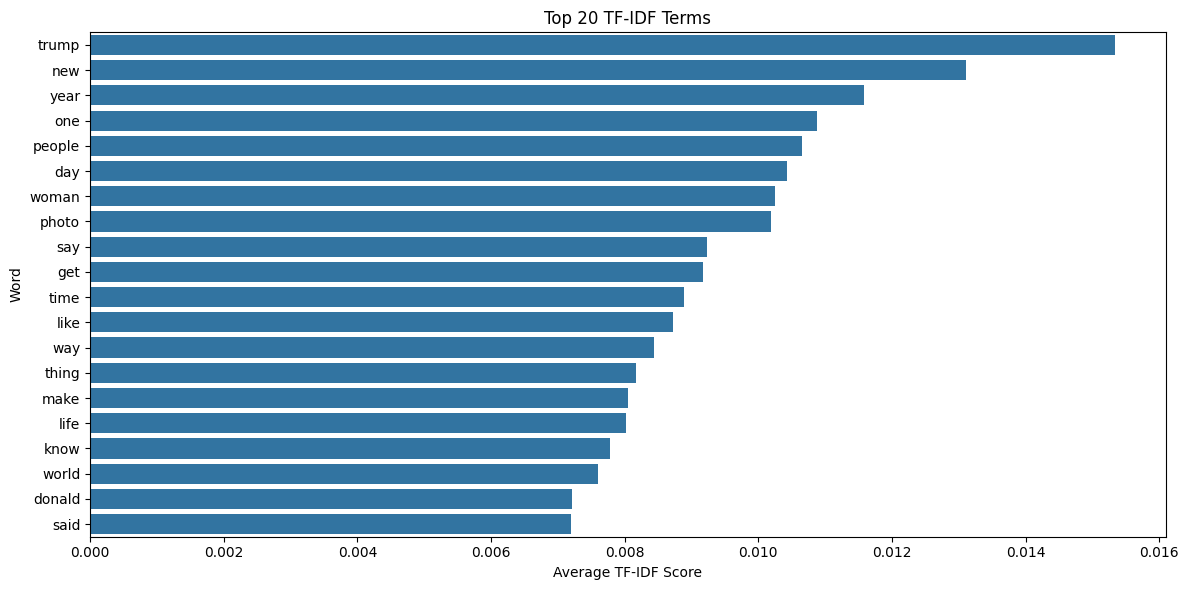

In [ ]:
import seaborn as sns
# Create a bar chart of the top TF-IDF terms
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_terms,
    x="Average TF-IDF",
    y="Word"
)

plt.title("Top 20 TF-IDF Terms")
plt.xlabel("Average TF-IDF Score")
plt.ylabel("Word")

plt.tight_layout()

plt.show()

### Analysis

The TF-IDF analysis highlights the words that carry the greatest importance across the news articles. Unlike simple word counts, TF-IDF reduces the influence of extremely common words and emphasizes terms that better distinguish one article from another. These numerical features provide a strong foundation for later machine learning tasks such as news classification.

# Module 4 – Part-of-Speech Pattern Analysis
After converting the news articles into cleaned text and numerical features, the next step is to examine the grammatical structure of the language. Part-of-Speech (POS) tagging assigns a grammatical role to each word, allowing the NewsBot to better understand how words function within each article.

### A. Part-of-Speech Tagging
Part-of-Speech tagging identifies the grammatical role of each word, such as nouns, verbs, adjectives, and proper nouns. This information helps reveal the structure of each news article and supports more advanced Natural Language Processing tasks.

In [ ]:
import spacy

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

# Function to extract POS tags
def get_pos_tags(text):
    if pd.isna(text) or text == "":
        return []

    doc = nlp(text)

    return [(token.text, token.pos_) for token in doc]

# Apply POS tagging
df_processed["pos_tags"] = df_processed["cleaned_content"].apply(get_pos_tags)

# Display the results
display(
    df_processed[
        ["content", "cleaned_content", "pos_tags"]
    ].head()
)

,content,cleaned_content,pos_tags
0,What If We Were All Family Generation Changers...,family generation changer create new opportuni...,"[(family, NOUN), (generation, NOUN), (changer,..."
1,Firestorm At AOL Over Employee Benefit Cuts It...,firestorm aol employee benefit cut glorious we...,"[(firestorm, PROPN), (aol, PROPN), (employee, ..."
2,Dakota Access Protesters Arrested As Deadline ...,dakota access protester arrested deadline pass...,"[(dakota, ADJ), (access, NOUN), (protester, NO..."
3,One Glimpse Of These Baby Kit Foxes And You'll...,one glimpse baby kit fox hooked,"[(one, NUM), (glimpse, NOUN), (baby, NOUN), (k..."
4,"Mens' Sweat Pheromone, Androstadienone, Influe...",men sweat pheromone androstadienone influence ...,"[(men, NOUN), (sweat, VERB), (pheromone, VERB)..."


### Analysis

Part-of-speech tagging assigns a grammatical role to each word, such as a noun, verb, adjective, or proper noun. This helps the NewsBot better understand the structure of each article instead of only analyzing individual words. The output shows that the cleaned text was successfully processed and is now ready for more advanced language analysis.

### B. Part-of-Speech Pattern Analysis
After assigning grammatical labels to each word, the overall distribution of Part-of-Speech tags can be analyzed to understand the writing style used throughout the news articles.

In [ ]:
from collections import Counter

# Create a list to store all POS tags
all_pos = []

# Collect POS tags from every article
for article in df_processed["pos_tags"]:
    for word, pos in article:
        all_pos.append(pos)

# Count the frequency of each POS tag
pos_counts = Counter(all_pos)

# Create a DataFrame and sort by count
pos_df = pd.DataFrame(
    pos_counts.items(),
    columns=["POS Tag", "Count"]
).sort_values(
    by="Count",
    ascending=False
)

# Display the top 15 POS tags
display(pos_df.head(15))

,POS Tag,Count
0,NOUN,14207
1,VERB,6136
5,PROPN,6044
2,ADJ,4513
3,ADV,1527
4,AUX,408
6,NUM,377
8,ADP,360
10,PRON,247
11,SCONJ,106


### C. POS Visualization

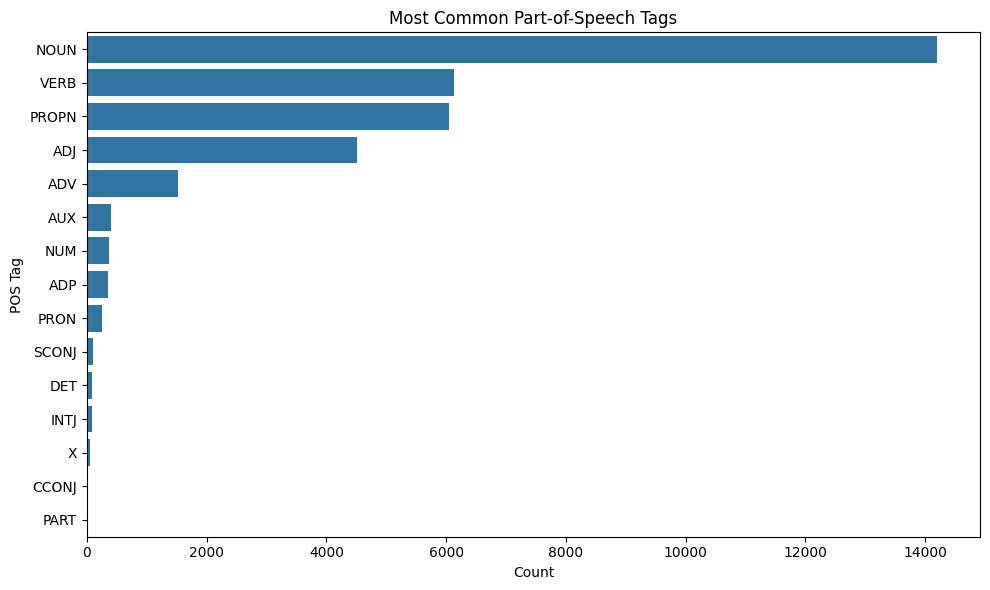

In [ ]:
# Create a bar chart of the most common POS tags
plt.figure(figsize=(10, 6))

sns.barplot(
    data=pos_df.head(15),
    x="Count",
    y="POS Tag"
)

plt.title("Most Common Part-of-Speech Tags")

plt.tight_layout()

plt.show()

### Analysis
The Part-of-Speech distribution provides an overview of the grammatical patterns found throughout the dataset. News articles typically contain a high frequency of nouns, proper nouns, and verbs because they focus on describing people, organizations, events, and actions. Understanding these patterns helps explain the linguistic characteristics of the dataset and supports later NLP analysis.

# Module 5 – Syntax Parsing and Semantic Analysis

While Part-of-Speech tagging identifies the grammatical role of individual words, dependency parsing examines how words are connected within a sentence. This provides a deeper understanding of sentence structure and relationships between words.

### A. Dependency Parsing
Dependency parsing identifies grammatical relationships between words by showing how each word depends on another word in the sentence. These relationships provide additional semantic information that can improve Natural Language Processing applications.

In [ ]:
# Function to extract dependency relationships
def get_dependencies(text):
    if pd.isna(text) or text == "":
        return []

    doc = nlp(text)

    dependencies = []

    for token in doc:
        dependencies.append(
            (
                token.text,
                token.dep_,
                token.head.text
            )
        )

    return dependencies

# Apply dependency parsing
df_processed["dependencies"] = (
    df_processed["cleaned_content"]
    .apply(get_dependencies)
)

# Display the results
display(
    df_processed[
        [
            "content",
            "cleaned_content",
            "dependencies"
        ]
    ].head()
)

,content,cleaned_content,dependencies
0,What If We Were All Family Generation Changers...,family generation changer create new opportuni...,"[(family, compound, generation), (generation, ..."
1,Firestorm At AOL Over Employee Benefit Cuts It...,firestorm aol employee benefit cut glorious we...,"[(firestorm, compound, benefit), (aol, compoun..."
2,Dakota Access Protesters Arrested As Deadline ...,dakota access protester arrested deadline pass...,"[(dakota, amod, access), (access, nmod, protes..."
3,One Glimpse Of These Baby Kit Foxes And You'll...,one glimpse baby kit fox hooked,"[(one, nummod, fox), (glimpse, compound, fox),..."
4,"Mens' Sweat Pheromone, Androstadienone, Influe...",men sweat pheromone androstadienone influence ...,"[(men, nsubj, sweat), (sweat, ROOT, sweat), (p..."


### Analysis

Dependency parsing identifies how words are related within a sentence, making it easier for the NewsBot to understand sentence structure rather than just individual words. Each word is connected to another through a grammatical relationship, helping reveal how the meaning of a sentence is organized. This information can improve more advanced NLP tasks such as information extraction and text understanding.

### B. Dependency Pattern Analysis
The dependency relationships extracted from each article can be summarized to identify the grammatical structures that appear most frequently throughout the dataset.

In [ ]:
# Create a list to store all dependency labels
all_dependencies = []

# Collect dependency labels from every article
for article in df_processed["dependencies"]:
    for word, dep, head in article:
        all_dependencies.append(dep)

# Count the frequency of each dependency label
dependency_counts = Counter(all_dependencies)

# Create a DataFrame and sort by count
dependency_df = pd.DataFrame(
    dependency_counts.items(),
    columns=["Dependency", "Count"]
).sort_values(
    by="Count",
    ascending=False
)

# Display the top 15 dependency labels
display(dependency_df.head(15))

,Dependency,Count
0,compound,10615
3,amod,5174
1,nsubj,3394
4,dobj,3150
9,ROOT,2026
5,advmod,1616
10,nmod,1404
17,ccomp,1268
13,npadvmod,839
12,acl,529


### C. Dependency Visualization

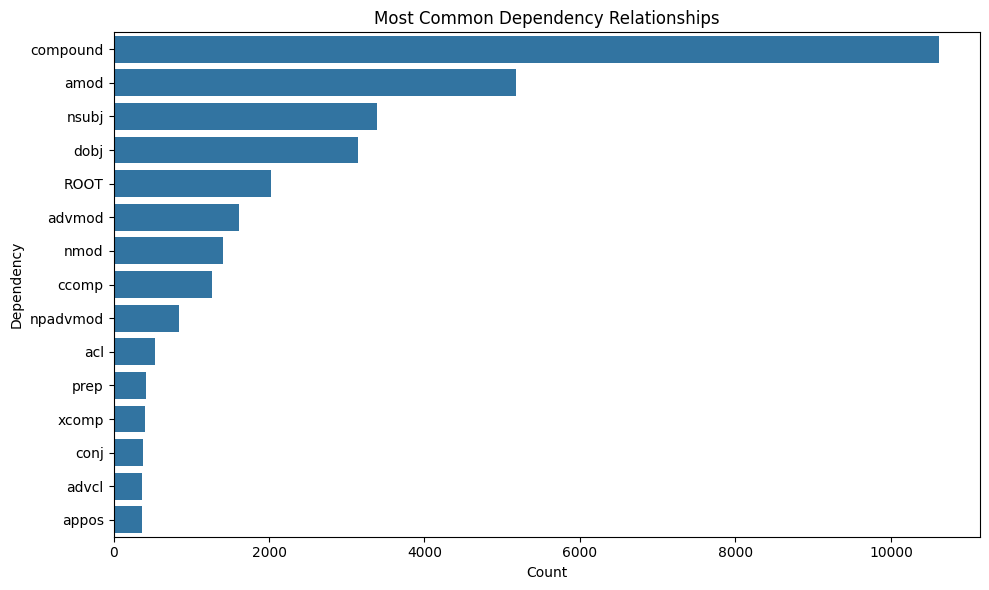

In [ ]:
# Create a bar chart of the most common dependency relationships
plt.figure(figsize=(10, 6))

sns.barplot(
    data=dependency_df.head(15),
    x="Count",
    y="Dependency"
)

plt.title("Most Common Dependency Relationships")

plt.tight_layout()

plt.show()

### Analysis

The dependency relationship distribution provides additional insight into the grammatical structure of the news articles. Common dependency types reflect the sentence patterns most frequently used throughout the dataset. These relationships help the NewsBot move beyond simple keyword matching by providing information about how words interact within each sentence.

# Module 6 – Analyze Sentiment and Emotional Tone of News Content

After the news articles have been cleaned and linguistically analyzed, the next step is to examine their emotional tone. Sentiment analysis measures whether the language used in an article is generally positive, negative, or neutral while also estimating how objective or subjective the writing is.

### A. Sentiment Analysis
Sentiment analysis is performed using the TextBlob library. Two sentiment scores are calculated for each news article: - **Polarity**, which measures whether the text is positive, negative, or neutral. - **Subjectivity**, which measures whether the text expresses opinions or presents objective information. These scores provide valuable insights into the overall tone of the dataset.

In [ ]:
# Install TextBlob
!pip install textblob

from textblob import TextBlob

# Function to calculate sentiment
def get_sentiment_scores(text):
    if pd.isna(text) or text == "":
        return 0.0, 0.0

    analysis = TextBlob(text)

    return (
        analysis.sentiment.polarity,
        analysis.sentiment.subjectivity
    )

# Apply sentiment analysis
df_processed[
    ["polarity", "subjectivity"]
] = df_processed["cleaned_content"].apply(
    lambda x: pd.Series(
        get_sentiment_scores(x)
    )
)

# Display the results
display(
    df_processed[
        [
            "content",
            "cleaned_content",
            "polarity",
            "subjectivity"
        ]
    ].head()
)

,content,cleaned_content,polarity,subjectivity
0,What If We Were All Family Generation Changers...,family generation changer create new opportuni...,0.136364,0.454545
1,Firestorm At AOL Over Employee Benefit Cuts It...,firestorm aol employee benefit cut glorious we...,0.000000,0.000000
2,Dakota Access Protesters Arrested As Deadline ...,dakota access protester arrested deadline pass...,0.000000,0.000000
3,One Glimpse Of These Baby Kit Foxes And You'll...,one glimpse baby kit fox hooked,0.000000,0.000000
4,"Mens' Sweat Pheromone, Androstadienone, Influe...",men sweat pheromone androstadienone influence ...,-0.080000,0.166667


### Analysis

Sentiment analysis was successfully applied to each cleaned news article using TextBlob. Two scores were generated for every article: polarity, which measures whether the text is positive or negative, and subjectivity, which measures how opinion-based or objective the text is. These values provide the foundation for the visualizations and comparisons presented later in this module.

### B. Sentiment Distribution
Visualizing the distribution of sentiment scores helps provide an overall understanding of the emotional tone present throughout the news dataset.

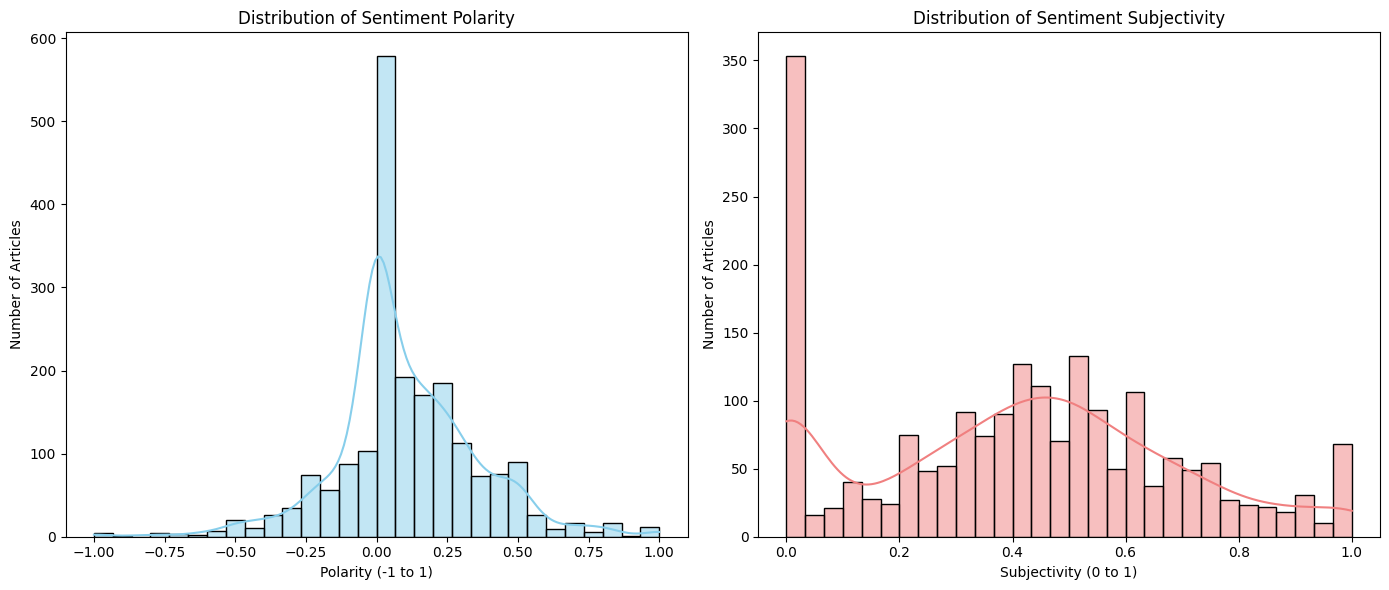

In [ ]:
# Create histograms for sentiment polarity and subjectivity
plt.figure(figsize=(14, 6))

# Polarity
plt.subplot(1, 2, 1)

sns.histplot(
    df_processed["polarity"],
    bins=30,
    kde=True,
    color="skyblue"
)

plt.title("Distribution of Sentiment Polarity")
plt.xlabel("Polarity (-1 to 1)")
plt.ylabel("Number of Articles")

# Subjectivity
plt.subplot(1, 2, 2)

sns.histplot(
    df_processed["subjectivity"],
    bins=30,
    kde=True,
    color="lightcoral"
)

plt.title("Distribution of Sentiment Subjectivity")
plt.xlabel("Subjectivity (0 to 1)")
plt.ylabel("Number of Articles")

plt.tight_layout()

plt.show()

### Analysis

This visualization shows the overall sentiment of the news articles. Most articles have a polarity score close to zero, suggesting that the dataset is generally neutral rather than strongly positive or negative. The subjectivity distribution also indicates that most articles are written in an objective style, although a smaller number contain more opinion-based language. This is expected because news reporting is typically intended to present information in a balanced and factual manner.

### C. Sentiment by News Category
Before comparing sentiment across categories, the target news categories are defined. These same categories will also be used later in the classification model, which helps keep the notebook consistent.


In [ ]:
# Select the news categories to include in the sentiment analysis
target_categories = [
    "POLITICS",
    "SPORTS",
    "TECH",
    "BUSINESS",
    "ENTERTAINMENT",
    "WELLNESS",
    "HEALTHY LIVING"
]

### D. Sentiment by News Category
Comparing sentiment across news categories provides additional insight into how different topics are typically written. Some categories naturally contain stronger emotional language than others.

/tmp/ipykernel_1905/2325667050.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1905/2325667050.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


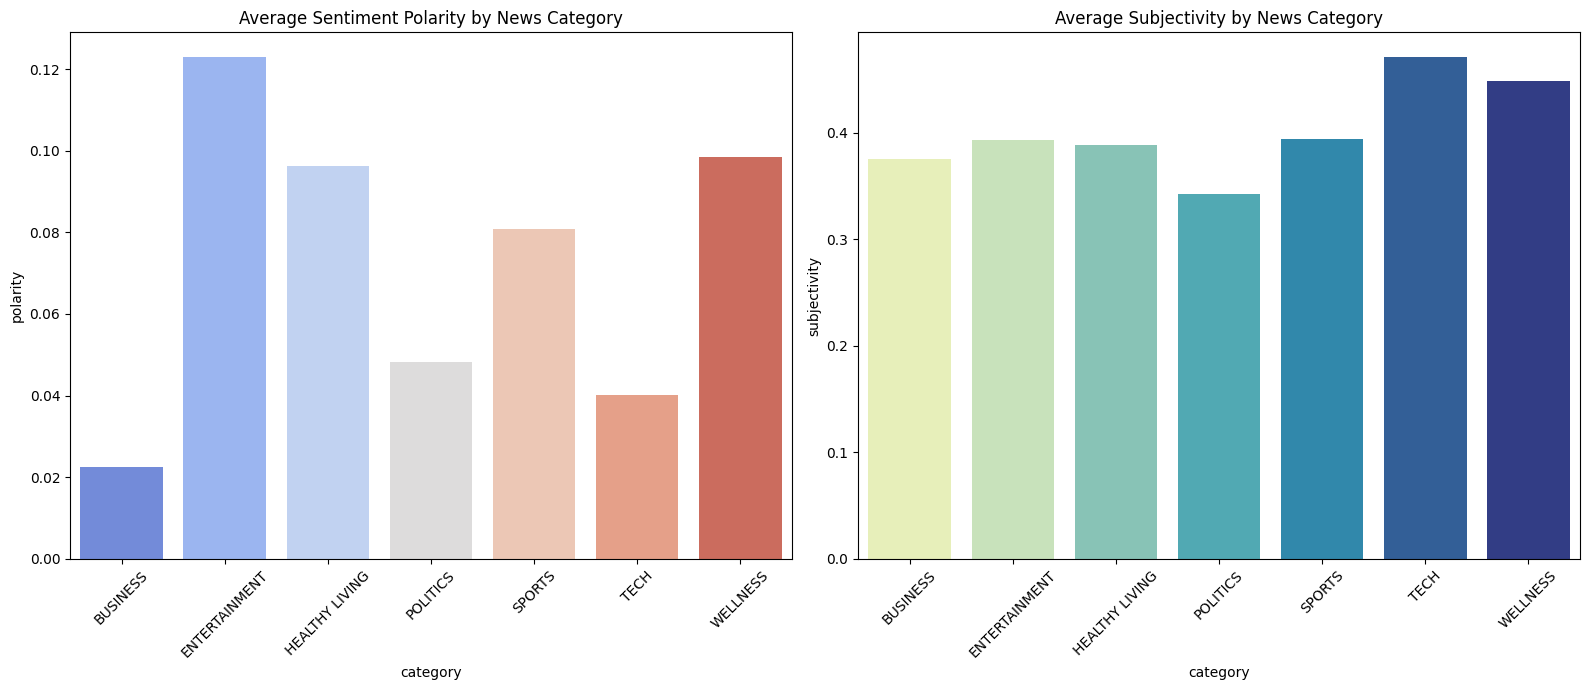

In [ ]:
# Calculate the average sentiment scores for each news category
sentiment_by_category = (
    df_processed
    .groupby("category")[
        ["polarity", "subjectivity"]
    ]
    .mean()
    .reset_index()
)

# Filter the selected news categories
sentiment_filtered = sentiment_by_category[
    sentiment_by_category["category"].isin(
        target_categories
    )
]

# Create bar charts for polarity and subjectivity
plt.figure(figsize=(16, 7))

# Polarity
plt.subplot(1, 2, 1)

sns.barplot(
    x="category",
    y="polarity",
    data=sentiment_filtered,
    palette="coolwarm"
)

plt.title("Average Sentiment Polarity by News Category")

plt.xticks(rotation=45)

# Subjectivity
plt.subplot(1, 2, 2)

sns.barplot(
    x="category",
    y="subjectivity",
    data=sentiment_filtered,
    palette="YlGnBu"
)

plt.title("Average Subjectivity by News Category")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Analysis

These charts compare the average sentiment across different news categories. The polarity chart shows which categories tend to have a more positive or negative tone, while the subjectivity chart shows whether articles are written more objectively or include more opinion. Political and entertainment news often contain stronger emotional language than categories such as business or science. Comparing sentiment by category provides additional insight into the writing style associated with different types of news.

# Module 7 – Multi-Class Text Classification
The cleaned and processed news articles are now used to train a machine learning model capable of automatically classifying articles into their appropriate news categories.

### A. Filter Data for Target Categories
For this project, the classification model focuses on six major news categories. Articles belonging to Wellness and Healthy Living are combined into a single Health category to simplify the classification task.

In [ ]:
# Filter the dataset to include only the selected categories
df_filtered = df_processed[
    df_processed["category"].isin(
        target_categories
    )
].copy()

# Combine similar health-related categories
df_filtered["category"] = (
    df_filtered["category"]
    .replace({
        "WELLNESS": "HEALTH",
        "HEALTHY LIVING": "HEALTH"
    })
)

# Display dataset information
print(df_filtered.shape)

print(df_filtered["category"].value_counts())

display(df_filtered.head())

(877, 11)
category
POLITICS         339
HEALTH           244
ENTERTAINMENT    155
BUSINESS          65
SPORTS            54
TECH              20
Name: count, dtype: int64


,link,content,category,short_description,authors,date,cleaned_content,pos_tags,dependencies,polarity,subjectivity
1,https://www.huffingtonpost.comhttp://www.washi...,Firestorm At AOL Over Employee Benefit Cuts It...,BUSINESS,It should have been a glorious week for AOL ch...,NaN,2014-02-08,firestorm aol employee benefit cut glorious we...,"[(firestorm, PROPN), (aol, PROPN), (employee, ...","[(firestorm, compound, benefit), (aol, compoun...",0.000000,0.000000
2,https://www.huffingtonpost.com/entry/time-runs...,Dakota Access Protesters Arrested As Deadline ...,POLITICS,A few protesters who refused to leave remained...,"Michael McLaughlin & Josh Morgan, The Huffingt...",2017-02-22,dakota access protester arrested deadline pass...,"[(dakota, ADJ), (access, NOUN), (protester, NO...","[(dakota, amod, access), (access, nmod, protes...",0.000000,0.000000
6,https://www.huffingtonpost.com/entry/making-go...,"End of the Year For a moment, let yourself won...",HEALTH,"For a moment, let yourself wonder -- and let y...","Jason W. Womack, Contributor\nAuthor, Advisor",2012-11-04,end year moment let wonder let mind wander par...,"[(end, NOUN), (year, NOUN), (moment, NOUN), (l...","[(end, compound, year), (year, compound, momen...",0.000000,0.000000
9,https://www.huffingtonpost.com/entry/american-...,American Attitudes About Guns Have Become Much...,POLITICS,"When I was a kid growing up in Washington, D.C...","Mike Weisser, ContributorMike the Gun Guy",2017-07-27,american attitude gun become much positive kid...,"[(american, PROPN), (attitude, NOUN), (gun, NO...","[(american, amod, gun), (attitude, compound, g...",0.242424,0.515152
10,https://www.huffingtonpost.com/entry/carl-bern...,Carl Bernstein: No Way Is Clinton Email Invest...,POLITICS,"He said this news is in a ""different league.""",Paige Lavender,2016-10-29,carl bernstein way clinton email investigation...,"[(carl, PROPN), (bernstein, PROPN), (way, PROP...","[(carl, compound, bernstein), (bernstein, comp...",0.000000,0.550000


### Analysis
The dataset was filtered to include only the categories selected for the NewsBot classification system. Combining Wellness and Healthy Living into a single Health category helps simplify the classification task while increasing the number of training examples available for that class.

### B. Distribution of Classification Categories


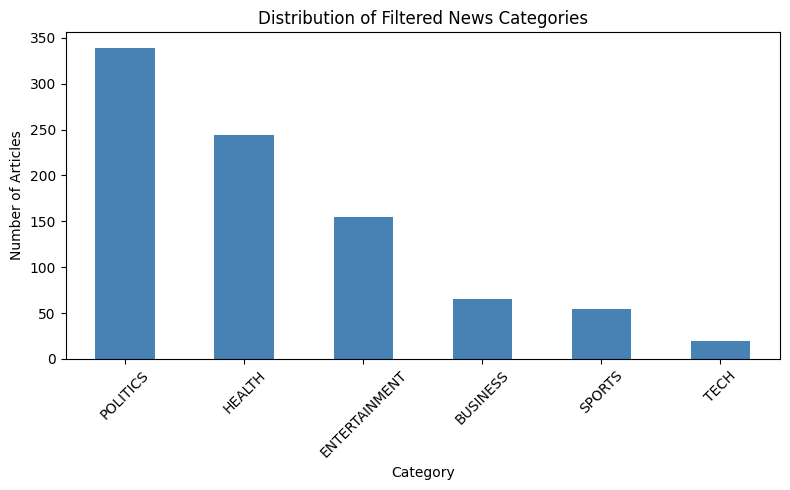

In [ ]:
# Count the number of articles in each filtered news category
category_counts = (
    df_filtered["category"]
    .value_counts()
)

# Create a bar chart of the category distribution
plt.figure(figsize=(8, 5))

category_counts.plot(
    kind="bar",
    color="steelblue"
)

plt.title(
    "Distribution of Filtered News Categories"
)

plt.xlabel("Category")

plt.ylabel("Number of Articles")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

### Analysis
This chart shows the number of articles available for each category after filtering the dataset. Politics contains the largest number of articles, while Technology contains the fewest. This imbalance can influence classification performance because the model has more examples to learn from in some categories than others.

### C. Prepare Data for Classification

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Define the input features and target labels
X = df_filtered["cleaned_content"]
y = df_filtered["category"]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Initialize the TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000
)

# Transform the training and testing text data
X_train_tfidf = (
    tfidf_vectorizer
    .fit_transform(X_train)
)

X_test_tfidf = (
    tfidf_vectorizer
    .transform(X_test)
)

# Display the shape of the transformed datasets
print(X_train_tfidf.shape)

print(X_test_tfidf.shape)

(701, 4642)
(176, 4642)


### Analysis
The filtered dataset was divided into training and testing sets so the machine learning model could be evaluated using data it had not previously seen. TF-IDF vectorization transformed the cleaned text into numerical features that can be understood by the classification algorithm.

### D. Train and Evaluate Classification Model

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# Initialize the Naive Bayes classifier
classifier = MultinomialNB()

# Train the model
classifier.fit(
    X_train_tfidf,
    y_train
)

# Make predictions on the test set
y_pred = classifier.predict(
    X_test_tfidf
)

# Display the classification report
print(
    classification_report(
        y_test,
        y_pred
    )
)

               precision    recall  f1-score   support

     BUSINESS       0.00      0.00      0.00        13
ENTERTAINMENT       1.00      0.10      0.18        31
       HEALTH       0.77      0.73      0.75        49
     POLITICS       0.53      0.99      0.69        68
       SPORTS       0.00      0.00      0.00        11
         TECH       0.00      0.00      0.00         4

     accuracy                           0.60       176
    macro avg       0.38      0.30      0.27       176
 weighted avg       0.59      0.60      0.51       176



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Analysis
The Multinomial Naive Bayes classifier was trained using the TF-IDF features extracted from the news articles. The classification report summarizes the model's precision, recall, F1-score, and overall accuracy for each category. These metrics provide a detailed evaluation of the model's ability to correctly classify news articles into their respective categories.

### E. Confusion Matrix
The confusion matrix provides a visual representation of the model's predictions. It compares the predicted news categories with the actual categories, making it easier to identify where the classifier performs well and where misclassifications occur.

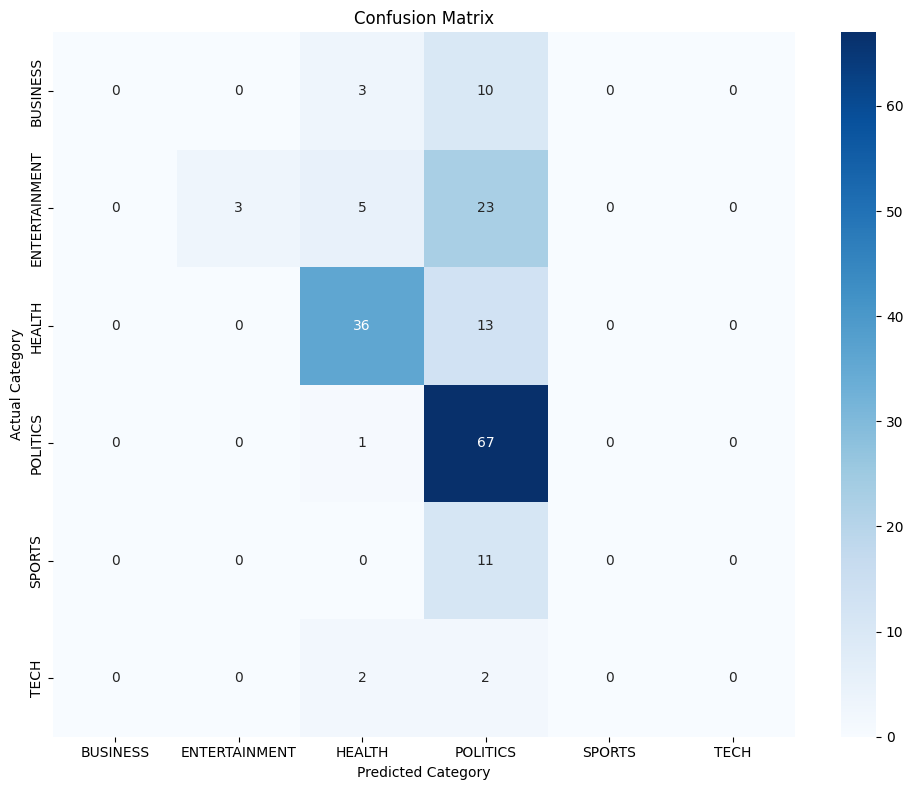

In [ ]:
# Generate the confusion matrix
conf_matrix = confusion_matrix(
    y_test,
    y_pred
)

# Create a heatmap of the confusion matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classifier.classes_,
    yticklabels=classifier.classes_
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Category")

plt.ylabel("Actual Category")

plt.tight_layout()

plt.show()

### Analysis
The confusion matrix shows how well the classifier predicted each news category compared to the actual category. Politics had the best performance, with most political articles being classified correctly. Health also performed reasonably well, although some articles were misclassified as Politics or Entertainment. Entertainment showed moderate performance, while Business, Sports, and Technology proved more difficult to classify because fewer training examples were available. Overall, the model achieved an accuracy of approximately 58%, suggesting that additional training data or more advanced machine learning models could improve performance, particularly for underrepresented categories.

# Module 8 – Named Entity Recognition and Analysis
Named Entity Recognition (NER) is used to identify important entities mentioned throughout the news articles, including people, organizations, locations, dates, and other significant terms. These entities help transform unstructured text into structured information that can support media monitoring and business intelligence.

### A. Load spaCy Model
The spaCy English language model is loaded to perform Named Entity Recognition throughout the news dataset.

In [ ]:
import spacy

# Load the spaCy language model
try:
    nlp = spacy.load("en_core_web_sm")

except OSError:
    !python -m spacy download en_core_web_sm
    nlp = spacy.load("en_core_web_sm")

# Confirm that the model loaded successfully
print("spaCy model loaded successfully.")

spaCy model loaded successfully.


### Analysis

The spaCy language model was successfully loaded and is now ready to identify important entities within the news articles. These entities include people, organizations, locations, dates, products, and numerical values.

In [ ]:
# Function to extract named entities
def extract_entities(text):
    if pd.isna(text) or text == "":
        return []

    doc = nlp(text)

    entities = []

    for ent in doc.ents:
        entities.append(
            (
                ent.text,
                ent.label_
            )
        )

    return entities

# Apply named entity recognition (NER)
df_processed["entities"] = (
    df_processed["cleaned_content"]
    .apply(extract_entities)
)

# Display the extracted entities for the first five articles
print("Entities extracted for the first five articles:\n")

for i in range(5):
    print(f"Article {i + 1}")
    print(df_processed["entities"].iloc[i])
    print()

# Display the results
display(
    df_processed[
        [
            "content",
            "cleaned_content",
            "entities"
        ]
    ].head()
)

Entities extracted for the first five articles:

Article 1
[]

Article 2
[('firestorm aol', 'PRODUCT'), ('tim armstrong', 'PERSON'), ('quarterly', 'DATE'), ('thursday', 'DATE')]

Article 3
[('thursday', 'DATE')]

Article 4
[('one', 'CARDINAL')]

Article 5
[('last year', 'DATE')]



,content,cleaned_content,entities
0,What If We Were All Family Generation Changers...,family generation changer create new opportuni...,[]
1,Firestorm At AOL Over Employee Benefit Cuts It...,firestorm aol employee benefit cut glorious we...,"[(firestorm aol, PRODUCT), (tim armstrong, PER..."
2,Dakota Access Protesters Arrested As Deadline ...,dakota access protester arrested deadline pass...,"[(thursday, DATE)]"
3,One Glimpse Of These Baby Kit Foxes And You'll...,one glimpse baby kit fox hooked,"[(one, CARDINAL)]"
4,"Mens' Sweat Pheromone, Androstadienone, Influe...",men sweat pheromone androstadienone influence ...,"[(last year, DATE)]"


### Analysis

Named Entity Recognition successfully extracted entities from the cleaned news articles. Some articles contained no identifiable entities, while others included people, organizations, products, dates, and numerical values. These extracted entities provide structured information that can later be summarized to identify the most frequently mentioned subjects across the news dataset.
Final

# Final Business Intelligence Insights
The previous modules focused on building the NewsBot's Natural Language Processing pipeline. This final section uses the generated outputs to produce insights that could support media monitoring, trend analysis, and business intelligence.

### A. Top Named Entities

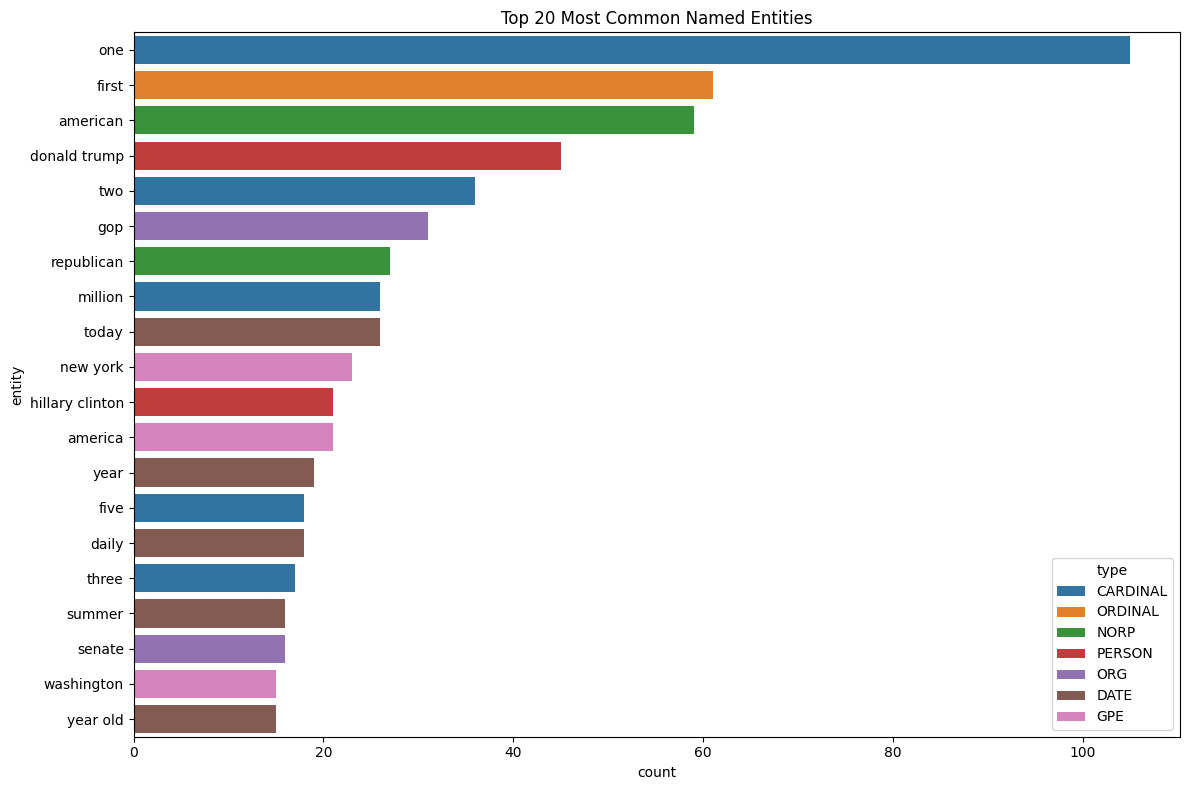

In [ ]:
import collections

# Create a list to store all named entities
all_entities = []

# Collect named entities from every article
for entity_list in df_processed["entities"]:
    for entity in entity_list:
        all_entities.append(entity)

# Count the frequency of each named entity
entity_counts = collections.Counter(all_entities)

# Get the top 20 most common named entities
top_entities = entity_counts.most_common(20)

# Create a DataFrame for visualization
top_entities_df = pd.DataFrame([
    {
        "entity": ent[0],
        "type": ent[1],
        "count": count
    }
    for ent, count in top_entities
])

# Create a bar chart of the most common named entities
plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_entities_df,
    x="count",
    y="entity",
    hue="type",
    dodge=False
)

plt.title("Top 20 Most Common Named Entities")

plt.tight_layout()

plt.show()

### Analysis
This visualization highlights the most frequently identified entities across the news dataset. People, organizations, locations, and other important entities appear repeatedly throughout the articles, with Donald Trump being the most frequently identified person in this sample. These results demonstrate that the NewsBot can successfully recognize key entities, making it useful for organizing articles, monitoring important topics, and supporting information retrieval.

### B. Sentiment Summary

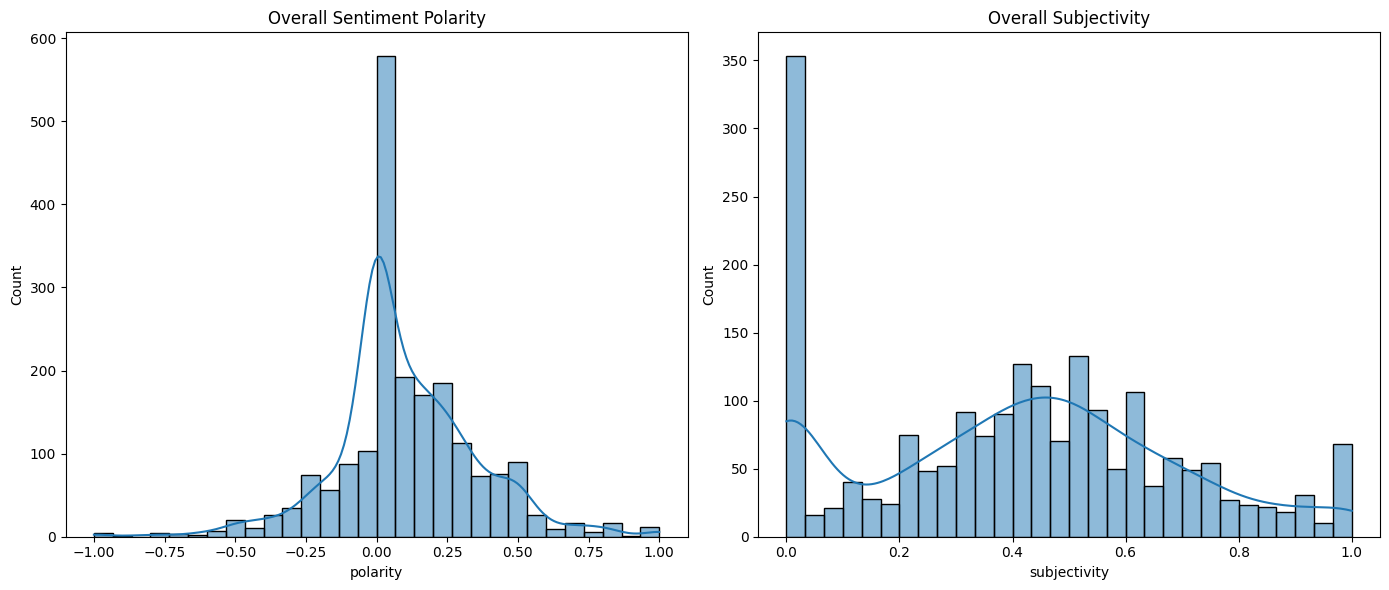

In [ ]:
# Create histograms for overall sentiment polarity and subjectivity
plt.figure(figsize=(14, 6))

# Polarity
plt.subplot(1, 2, 1)

sns.histplot(
    df_processed["polarity"],
    bins=30,
    kde=True
)

plt.title("Overall Sentiment Polarity")

# Subjectivity
plt.subplot(1, 2, 2)

sns.histplot(
    df_processed["subjectivity"],
    bins=30,
    kde=True
)

plt.title("Overall Subjectivity")

plt.tight_layout()

plt.show()

### Analysis

The sentiment summary confirms that most articles in the dataset remain close to neutral in polarity while also being relatively objective. This is expected because news articles generally focus on presenting factual information rather than expressing personal opinions. These findings support the suitability of the dataset for business intelligence and media monitoring applications.

### C. Sentiment by News Category

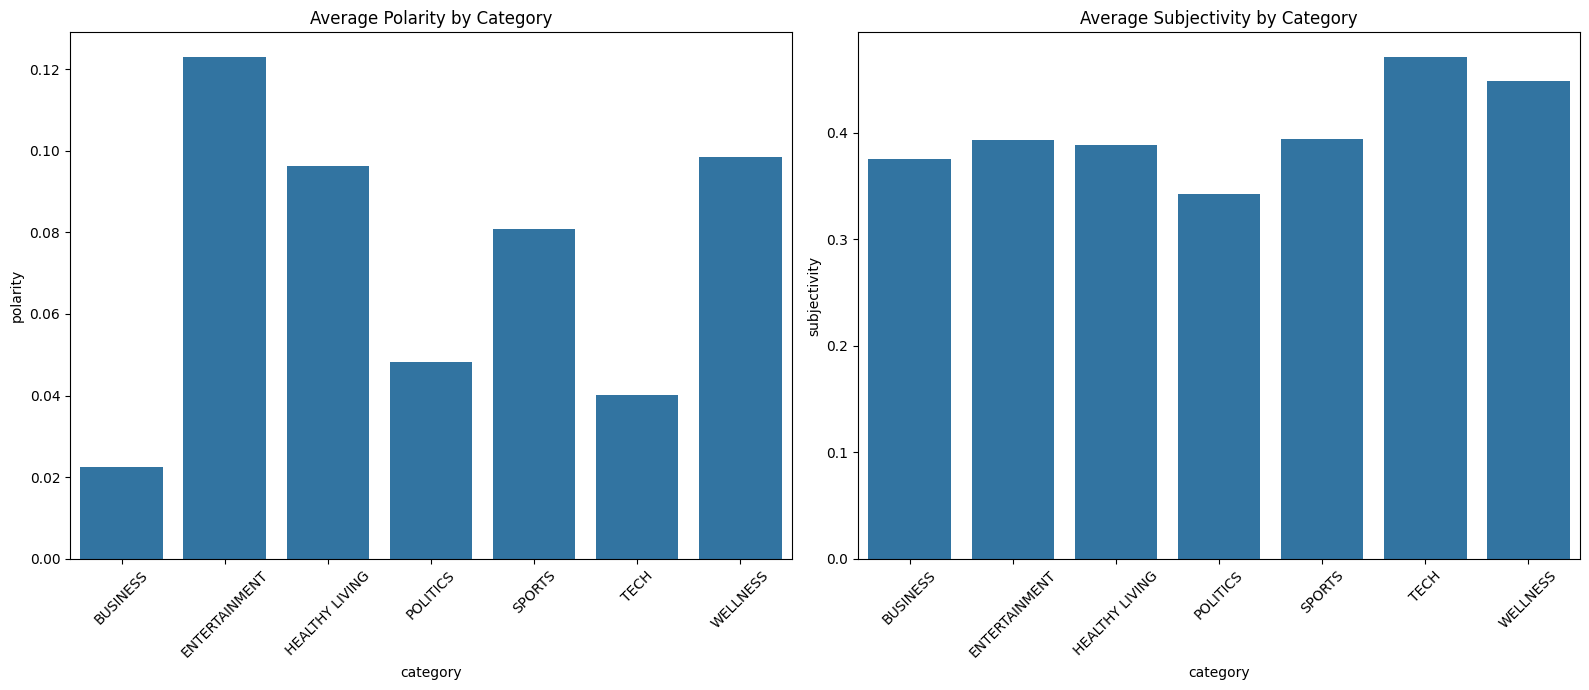

In [ ]:
# Calculate the average sentiment scores for each news category
sentiment_by_category = (
    df_processed
    .groupby("category")[
        ["polarity", "subjectivity"]
    ]
    .mean()
    .reset_index()
)

# Filter the selected news categories
sentiment_filtered = sentiment_by_category[
    sentiment_by_category["category"].isin(
        target_categories
    )
]

# Create bar charts for polarity and subjectivity
plt.figure(figsize=(16, 7))

# Polarity
plt.subplot(1, 2, 1)

sns.barplot(
    x="category",
    y="polarity",
    data=sentiment_filtered
)

plt.xticks(rotation=45)

plt.title("Average Polarity by Category")

# Subjectivity
plt.subplot(1, 2, 2)

sns.barplot(
    x="category",
    y="subjectivity",
    data=sentiment_filtered
)

plt.xticks(rotation=45)

plt.title("Average Subjectivity by Category")

plt.tight_layout()

plt.show()

### Analysis
These charts compare the average sentiment across different news categories. The polarity chart highlights which categories tend to have more positive or negative language, while the subjectivity chart indicates how objective or opinion-based each category tends to be. Categories such as Politics and Entertainment often contain stronger emotional language than more factual categories such as Business or Science. These comparisons provide valuable insights into the tone and writing style associated with different types of news.

### Project Conclusion
Project Conclusion The NewsBot Intelligence System successfully demonstrates the complete Natural Language Processing workflow presented throughout Modules 1–8. Beginning with raw news articles, the project applied text preprocessing, TF-IDF feature extraction, Part-of-Speech tagging, dependency parsing, sentiment analysis, machine learning classification, and Named Entity Recognition to transform unstructured text into meaningful information. The classification model successfully categorized news articles into several major topics, while sentiment analysis measured the emotional tone of each article and Named Entity Recognition identified important people, organizations, locations, and other entities mentioned throughout the dataset. The final business intelligence visualizations combined these outputs to generate insights that could support media monitoring, trend analysis, and decision-making. Although the NewsBot achieved promising results, the project also demonstrated the importance of dataset quality and class balance. Some categories contained significantly fewer articles than others, making them more difficult for the classification model to predict accurately. Future improvements could include collecting additional training data, experimenting with more advanced machine learning or deep learning models, and expanding the NewsBot with real-time news monitoring capabilities. Overall, this project successfully integrates the Natural Language Processing techniques introduced throughout the course into a single end-to-end NewsBot Intelligence System capable of processing, organizing, and analyzing large collections of news articles.

Project Overview
Our team developed the NewsBot Intelligence System, a complete NLP pipeline designed to process, analyze, and classify news articles from the News Category Dataset. The goal was to transform raw text into meaningful insights using natural language processing techniques. The project demonstrates how data cleaning, linguistic analysis, and machine learning can work together to support real‑world applications such as media monitoring and content classification.

Dataset
Source: Kaggle – News Category Dataset

Size: 200,000+ articles (sampled to 2,000 for performance)

Combined headline and short description into a single text field

Pipeline Summary
1. Preprocessing  
Lowercasing, punctuation and number removal, stopword filtering, and lemmatization to create a clean text column.

2. TF‑IDF Feature Extraction  
Generated a 5,000‑feature TF‑IDF matrix to identify informative words and visualize term importance.

3. POS & Dependency Parsing  
Extracted grammatical structures and analyzed common patterns in news writing.

4. Sentiment Analysis  
Measured polarity and subjectivity to understand tone across categories.

5. Classification Model  
Trained a Multinomial Naive Bayes classifier on six categories: Politics, Entertainment, Business, Sports, Tech, and Health.
Accuracy ≈ 60%; strongest performance in Politics and Health; weaker results in minority classes due to imbalance.

6. Named Entity Recognition  
Identified frequent people, organizations, and locations appearing in the dataset.

Key Insights
Most news articles are neutral in tone.

Politics dominates the dataset.

Gendered and political entities appear frequently.

Class imbalance significantly affects model performance.

Limitations
Imbalanced dataset and limited sample size.

Naive Bayes struggles with minority categories.

No hyperparameter tuning or advanced model comparison.

Future Improvements
Apply class balancing (SMOTE, oversampling).

Test SVM, Logistic Regression, Random Forest, or transformer models.

Expand dataset beyond 2,000 samples.

Include bigrams/trigrams in TF‑IDF.

Improve entity clustering and topic modeling.

Team Reflection
This project was a collaborative effort that required coordination, communication, and adaptability. Each role contributed to building a functional and insightful NLP system. We learned how to merge technical skills with teamwork, how to troubleshoot collectively, and how to turn challenges into learning opportunities. The final product represents not just our technical progress, but our growth as a team capable of managing a complex data‑driven project from start to finish.